# **Final Notebook: Handcrafted Window Features**

In [1]:
#imports
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if os.getcwd().endswith("notebooks_final"):
    os.chdir("../")
from thesis_package.features.local_feature_extractor import WindowFeatureExtractor
from thesis_package.features.aggregation import aggregate_window_features
from thesis_package.models.analysis import leakage_free_residual_analysis
from thesis_package.models.baseline_loso import evaluate_loso_model

In [ ]:
from thesis_package.data.loaders import get_eligible_files, load_processed_dict, load_scores_df

# Load processed trajectory dataframes
eligible = get_eligible_files(processed_dir="../data/processed/landmark_dataframes2/",
                              vid_name_map_path="../data/scores/vid_name_map.csv",)
df_dict = load_processed_dict(eligible)

# load scores
load_scores_df("../data/scores/merged_scores.csv")

# extract window features
extractor = WindowFeatureExtractor(hand="Right", window_sec=1.5, step_sec=0.5)
df_window_features = extractor.extract_features(df_dict)

In [2]:
processed_path = "data/processed/landmark_dataframes2/"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)#[cols_to_keep]
        pbar.update(1)

df_dict = dict(sorted(df_dict.items()))

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

Loading processed data:  97%|█████████▋| 83/86 [00:03<00:00, 22.47it/s]


In [ ]:
# 1. Initialize and Prepare Data
extractor = WindowFeatureExtractor(hand="Right", window_sec=1.5, step_sec=0.5, log_transform=True, include_bimanual=True, exclude_idle=False)
df_window_features = extractor.extract_features(df_dict)

Extracting Right Features: 100%|██████████| 83/83 [01:22<00:00,  1.00it/s]


In [4]:
extractor = WindowFeatureExtractor(hand="Left", window_sec=1.5, step_sec=0.5, log_transform=True, include_bimanual=True, exclude_idle=False)
df_window_features_left = extractor.extract_features(df_dict)

Extracting Left Features: 100%|██████████| 83/83 [01:33<00:00,  1.13s/it]


In [4]:
feature_cols = [col for col in df_window_features.columns if col not in ['video_id', 'window_start_frame']]

In [13]:
df_window_features[feature_cols].corr()

,total_path,is_idle,path_ratio,spatial_spread,sparc,hf_ratio,speed_peaks,acc_rms,palm_area_cv,bimanual_dist_mean,bimanual_dist_std,bimanual_sync,bimanual_ratio
total_path,1.000000,-0.180728,0.120434,0.813686,0.185867,-0.110774,-0.289896,0.805188,0.492878,0.047951,0.639694,0.155207,0.389303
is_idle,-0.180728,1.000000,-0.052644,-0.349092,-0.134187,0.118854,0.203214,-0.375199,-0.180055,0.032837,-0.126736,-0.048229,-0.184767
path_ratio,0.120434,-0.052644,1.000000,-0.175343,-0.262630,0.495740,0.417562,0.338288,0.298444,-0.035818,-0.190898,-0.213191,0.285807
spatial_spread,0.813686,-0.349092,-0.175343,1.000000,0.375342,-0.432294,-0.561142,0.760111,0.438580,0.036815,0.642767,0.217852,0.358799
sparc,0.185867,-0.134187,-0.262630,0.375342,1.000000,-0.569512,-0.486935,0.126263,0.021940,0.041907,0.240106,0.152936,0.034778
hf_ratio,-0.110774,0.118854,0.495740,-0.432294,-0.569512,1.000000,0.679688,0.028454,0.087630,-0.053948,-0.330614,-0.212748,0.085074
speed_peaks,-0.289896,0.203214,0.417562,-0.561142,-0.486935,0.679688,1.000000,-0.168123,-0.010742,-0.079564,-0.381177,-0.276828,-0.026202
acc_rms,0.805188,-0.375199,0.338288,0.760111,0.126263,0.028454,-0.168123,1.000000,0.628949,-0.019668,0.444287,0.061870,0.536753
palm_area_cv,0.492878,-0.180055,0.298444,0.438580,0.021940,0.087630,-0.010742,0.628949,1.000000,-0.109279,0.252015,-0.009344,0.329462
bimanual_dist_mean,0.047951,0.032837,-0.035818,0.036815,0.041907,-0.053948,-0.079564,-0.019668,-0.109279,1.000000,0.052870,-0.053819,0.141732


In [ ]:
#df_window_features_right = df_window_features
#df_window_features = df_window_features_right
#df_window_features = df_window_features_left

In [14]:
df_bimanual = df_window_features[df_window_features['bimanual_dist_mean'].notna()]
print(len(df_bimanual), "bimanual windows out of", len(df_window_features))

52956 bimanual windows out of 66805


In [5]:
import numpy as np

def aggregate_window_features(df_windows, p=90, active_with_idle=True):
    """
    Aggregates window-level features into video-level descriptors, 
    separating 'Decision Time' (Idle) from 'Execution Quality' (Active).
    """
    
    # --- 1. Pre-Aggregation Feature Engineering ---
    # Convert raw Bimanual Ratio (0-1) into "Hand Bias" (0.0=Balanced, 0.5=One-handed)
    # We do this here because the variance of the raw ratio is ambiguous.
    if 'bimanual_ratio' in df_windows.columns:
        df_windows['bimanual_imbalance'] = (df_windows['bimanual_ratio'] - 0.5).abs()

    # --- 2. Global Economy (The "Hesitation" Signal) ---
    # We use the whole dataframe (Idle + Active) for this
    df_economy = df_windows.groupby('video_id')['is_idle'].agg(
        idle_prop='mean'      # % of time spent waiting
    )

    # --- 3. Active Kinematics (The "Skill" Signal) ---
    # Filter for active windows only
    if not active_with_idle:
        df_active = df_windows[df_windows['is_idle'] == 0].copy()
    else:
        df_active = df_windows.copy()
    
    
    # Define aggregation strategies based on feature type
    # A. Magnitude Features (Where the 'Average' matters)
    #    Velocity, Spacing, Ang Velocity
    possible_feats = [
        'spatial_spread', 'acc_rms', 'hf_ratio', 'path_ratio', 
        'sparc', 'palm_area_cv', 'speed_peaks'
    ]
    
    # Filter lists to ensure columns actually exist
    feats = [c for c in possible_feats if c in df_active.columns]

    # helper for clean names
    def make_percentile_funcs(p):
        def high(x):
            return np.percentile(x, p)
        def low(x):
            return np.percentile(x, 100-p)

        high.__name__ = f"p{p}"
        low.__name__  = f"p{100-p}"

        return high, low


    p_high, p_low = make_percentile_funcs(p)

    
    aggs = {}
    
    for f in feats:
        aggs[f] = ['mean', 'std', p_high, p_low]

    df_kinematics = df_active.groupby('video_id').agg(aggs)
    
    # --- 4. Flatten MultiIndex Columns Cleanly ---
    # Result: vel_mean_median, jerk_max, etc.
    df_kinematics.columns = [f"{c[0]}_{c[1]}" for c in df_kinematics.columns]

    # --- 5. Merge ---
    df_final = df_economy.join(df_kinematics, how='left')

    bimanual_feats = ['bimanual_dist_mean', 'bimanual_dist_std', 'bimanual_sync', 'bimanual_imbalance']

    if all(f in df_windows.columns for f in bimanual_feats):
        df_bimanual = df_windows[df_windows['bimanual_dist_mean'].notna() &
                                 df_windows['bimanual_dist_std'].notna() & 
                                 df_windows['bimanual_sync'].notna() & 
                                 df_windows['bimanual_imbalance'].notna()][['video_id']+bimanual_feats]
        
        aggs = {}
    
        for f in bimanual_feats:
            aggs[f] = ['median', 'std', p_high, p_low]

        df_bimanual_agg = df_bimanual.groupby('video_id').agg(aggs)
        df_bimanual_agg.columns = [f"{c[0]}_{c[1]}" for c in df_bimanual_agg.columns]
        df_final = df_final.join(df_bimanual_agg, how='left')
    
    return df_final.reset_index()

In [6]:
# Usage
df_window_features['is_idle'] = (df_window_features['total_path'] < 45).astype(int)
df_agg = aggregate_window_features(df_window_features, p=90, active_with_idle=False)

In [96]:
df_agg2 = aggregate_window_features(df_window_features, p=75, active_with_idle=False)
cols = [col for col in df_agg2.columns if 'p90' in col or 'p10' in col]
# merge distinct columns of df_agg and df_agg2
#df_agg = df_agg.merge(df_agg2[cols + ['video_id']], on=['video_id'])

In [7]:
from scipy.stats import pearsonr, spearmanr

candidate_features = [col for col in df_agg.columns if col not in ['video_id']]
scores = list(grs_scores.values())

#shuffle scores
import random
#random.seed(42)
#random.shuffle(scores)

feature_df = df_agg[candidate_features]
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
features = list(feature_df.columns)
pearson_corrs = []
spearman_corrs = []
for i in range(feature_df.shape[1]):
    pearson_corr, _ = pearsonr(feature_df.iloc[:, i], scores)
    spearman_corr, _ = spearmanr(feature_df.iloc[:, i], scores)
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 15 features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:10]
for idx in top_pearson_indices:
    print(f"{features[idx]}:        Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 15 features by Pearson correlation:
speed_peaks_std:        Pearson r = 0.4465, Spearman rho = 0.4677
hf_ratio_p90:        Pearson r = 0.4170, Spearman rho = 0.4451
hf_ratio_mean:        Pearson r = 0.4072, Spearman rho = 0.4146
path_ratio_mean:        Pearson r = 0.4072, Spearman rho = 0.4379
path_ratio_p90:        Pearson r = 0.4022, Spearman rho = 0.4465
palm_area_cv_mean:        Pearson r = 0.3966, Spearman rho = 0.3879
hf_ratio_std:        Pearson r = 0.3693, Spearman rho = 0.4182
speed_peaks_p90:        Pearson r = 0.3677, Spearman rho = 0.3372
palm_area_cv_p10:        Pearson r = 0.3056, Spearman rho = 0.3113
speed_peaks_mean:        Pearson r = 0.3043, Spearman rho = 0.2834


In [18]:
# load top feature df and combine with aggregated window features
df_top_features = pd.read_csv("data/metrics/top_features_df.csv")
df_pc1_features = pd.read_csv("data/metrics/global_pc1_features.csv")
df_pc1_features = pd.read_csv("data/metrics/pc1_features.csv")

df_combined = pd.merge(df_pc1_features, df_agg, left_index=True, right_index=True)

In [19]:
# one hot encode Case_Number
df_case_onehot = pd.get_dummies(df_combined['Case_Number'], prefix='Case').astype(int)

if not any('Case_1' in col for col in df_combined.columns):
    df_combined = pd.concat([df_combined, df_case_onehot], axis=1)

In [25]:
candidate_features

['idle_prop',
 'spatial_spread_median',
 'spatial_spread_std',
 'spatial_spread_p90',
 'spatial_spread_p10',
 'acc_rms_median',
 'acc_rms_std',
 'acc_rms_p90',
 'acc_rms_p10',
 'hf_ratio_median',
 'hf_ratio_std',
 'hf_ratio_p90',
 'hf_ratio_p10',
 'path_ratio_median',
 'path_ratio_std',
 'path_ratio_p90',
 'path_ratio_p10',
 'sparc_median',
 'sparc_std',
 'sparc_p90',
 'sparc_p10',
 'palm_area_cv_median',
 'palm_area_cv_std',
 'palm_area_cv_p90',
 'palm_area_cv_p10',
 'speed_peaks_median',
 'speed_peaks_std',
 'speed_peaks_p90',
 'speed_peaks_p10',
 'bimanual_dist_mean_median',
 'bimanual_dist_mean_std',
 'bimanual_dist_mean_p90',
 'bimanual_dist_mean_p10',
 'bimanual_dist_std_median',
 'bimanual_dist_std_std',
 'bimanual_dist_std_p90',
 'bimanual_dist_std_p10',
 'bimanual_sync_median',
 'bimanual_sync_std',
 'bimanual_sync_p90',
 'bimanual_sync_p10',
 'bimanual_imbalance_median',
 'bimanual_imbalance_std',
 'bimanual_imbalance_p90',
 'bimanual_imbalance_p10']

In [27]:
top_features = [c for c in df_pc1_features.columns if '(R)' in c]

#top_features = ['angular_dir_switches_Right']

candidate_features = [col for col in df_combined.columns if col not in ['Participant Number', 'Case_Number', 'GRS_Total', 'QRS_Overal', 'video_id', 'velocity_corr', 'Case_1', 'Case_2', 'Case_3', 'idle_prop'] + top_features]

#candidate_features = [col for col in candidate_features if 'Bimanual' not in col]

#candidate_features.remove('velocity_ratio')
df_res_leakage_free = leakage_free_residual_analysis(df_combined, top_features, base_features=['Case_1', 'Case_2', 'Case_3'], candidate_features=candidate_features, top_n=1)
df_res_leakage_free


,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
36,spatial_spread_median,0.107770,0.014913,0.080682,-0.299781,1.0
10,bimanual_dist_std_p90,0.049442,0.011487,0.026749,-0.217456,0.0
2,acc_rms_p90,0.032815,0.009963,0.013376,-0.118423,0.0
16,bimanual_sync_median,0.032708,0.007801,0.014159,-0.173342,0.0
38,spatial_spread_p90,0.032667,0.009323,0.015186,-0.176412,0.0
11,bimanual_dist_std_std,0.025818,0.010108,0.005475,-0.155970,0.0
37,spatial_spread_p10,0.025589,0.007209,0.014580,-0.125733,0.0
15,bimanual_imbalance_std,0.024219,0.007747,0.012231,0.128684,0.0
3,acc_rms_std,0.023931,0.009293,0.004202,-0.141662,0.0
7,bimanual_dist_mean_std,0.020556,0.006603,0.012492,-0.144019,0.0


In [28]:
# top_features intercorrelation
top_candidates = df_res_leakage_free['Feature'].values[:5].tolist()
df_combined[top_candidates].corr()

,spatial_spread_median,bimanual_dist_std_p90,acc_rms_p90,bimanual_sync_median,spatial_spread_p90
spatial_spread_median,1.000000,0.447071,0.555285,0.170514,0.201474
bimanual_dist_std_p90,0.447071,1.000000,0.350411,0.012887,0.560841
acc_rms_p90,0.555285,0.350411,1.000000,-0.182553,0.256037
bimanual_sync_median,0.170514,0.012887,-0.182553,1.000000,-0.056333
spatial_spread_p90,0.201474,0.560841,0.256037,-0.056333,1.000000


In [29]:
# Do the distributions of the top features seem reasonable?
df_agg[top_candidates].describe()

,spatial_spread_median,bimanual_dist_std_p90,acc_rms_p90,bimanual_sync_median,spatial_spread_p90
count,83.000000,83.000000,83.000000,83.000000,83.000000
mean,3.041998,43.813966,7.906183,0.111013,4.317667
std,0.146862,7.867152,0.230427,0.048359,0.191028
min,2.582541,24.921513,7.506973,0.001206,3.746934
25%,2.946544,38.651386,7.743095,0.073026,4.179951
50%,3.043103,43.576806,7.896982,0.110737,4.320160
75%,3.133924,50.172735,8.007881,0.143051,4.463175
max,3.475805,61.442823,8.487704,0.234858,4.694612


In [30]:
candidate_features

['spatial_spread_median',
 'spatial_spread_std',
 'spatial_spread_p90',
 'spatial_spread_p10',
 'acc_rms_median',
 'acc_rms_std',
 'acc_rms_p90',
 'acc_rms_p10',
 'hf_ratio_median',
 'hf_ratio_std',
 'hf_ratio_p90',
 'hf_ratio_p10',
 'path_ratio_median',
 'path_ratio_std',
 'path_ratio_p90',
 'path_ratio_p10',
 'sparc_median',
 'sparc_std',
 'sparc_p90',
 'sparc_p10',
 'palm_area_cv_median',
 'palm_area_cv_std',
 'palm_area_cv_p90',
 'palm_area_cv_p10',
 'speed_peaks_median',
 'speed_peaks_std',
 'speed_peaks_p90',
 'speed_peaks_p10',
 'bimanual_dist_mean_median',
 'bimanual_dist_mean_std',
 'bimanual_dist_mean_p90',
 'bimanual_dist_mean_p10',
 'bimanual_dist_std_median',
 'bimanual_dist_std_std',
 'bimanual_dist_std_p90',
 'bimanual_dist_std_p10',
 'bimanual_sync_median',
 'bimanual_sync_std',
 'bimanual_sync_p90',
 'bimanual_sync_p10',
 'bimanual_imbalance_median',
 'bimanual_imbalance_std',
 'bimanual_imbalance_p90',
 'bimanual_imbalance_p10']

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 53.05it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7372 | MAE: 4.9340 | MAE STD: 3.9240 | R2: 0.5413 | Adj R2: 0.5051

Feature Weights:
                 Feature  Average_Weight  Std_Weight
0                   bias       49.981393    0.300964
1                    PC1       -5.908549    0.160422
2                 Case_1       -2.008288    0.125286
3                 Case_2       -1.534024    0.185655
4                 Case_3        3.542312    0.160269
5  spatial_spread_median       -2.263498    0.153998

--- Per-Fold Performance Summary ---
    Train_MAE   Test_MAE  Test_Corr
1    4.616736   3.966617   0.650201
2    4.623947   3.738555   0.816952
3    4.462841  10.837322   0.998954
4    4.680279   2.326780   0.400269
5    4.472318   7.883026   0.524706
6    4.747424   0.586868   0.999017
7    4.454979   7.653309  -0.949331
9    4.638402   4.481095  -0.070727
10   4.652201   3.909292   0.302710
11   4.660183   2.840212  -0.765103
12   4.685489   2.918596   0.299866
13   4.671159   3.116515   0

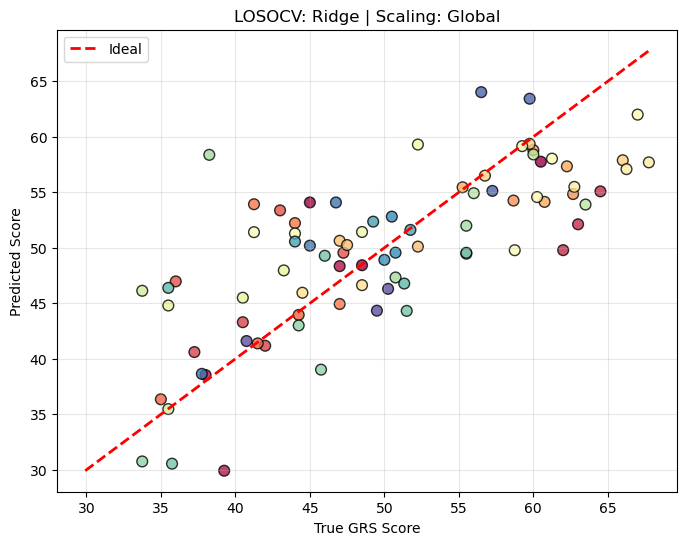

In [21]:
_, _, _ = evaluate_loso_model(df_combined, top_features, pca_components=[0], extra_features=['Case_1', 'Case_2', 'Case_3', 'spatial_spread_median'], print_fold_metrics=True)

In [36]:
candidate_features = [c for c in candidate_features if 'bimanual' not in c] + ['Case_1', 'Case_2', 'Case_3']

LOSOCV Folds:   0%|          | 0/28 [00:00<?, ?it/s]

LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 18.59it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7024 | MAE: 5.2290 | MAE STD: 4.2136 | R2: 0.4795 | Adj R2: 0.1289

Feature Weights:
                  Feature  Average_Weight  Std_Weight
0                    bias       49.938586    0.302804
1                     PC1       -4.516782    0.193276
2   spatial_spread_median       -2.331197    0.204212
3      spatial_spread_std        0.000000    0.000000
4      spatial_spread_p90       -0.584651    0.295090
5      spatial_spread_p10        0.012713    0.066056
6          acc_rms_median        0.017378    0.063363
7             acc_rms_std        0.000000    0.000000
8             acc_rms_p90        0.006658    0.034594
9             acc_rms_p10        0.000000    0.000000
10        hf_ratio_median        0.000000    0.000000
11           hf_ratio_std        0.000000    0.000000
12           hf_ratio_p90        0.000000    0.000000
13           hf_ratio_p10        0.000000    0.000000
14      path_ratio_median        0.394137    0.267846
15   

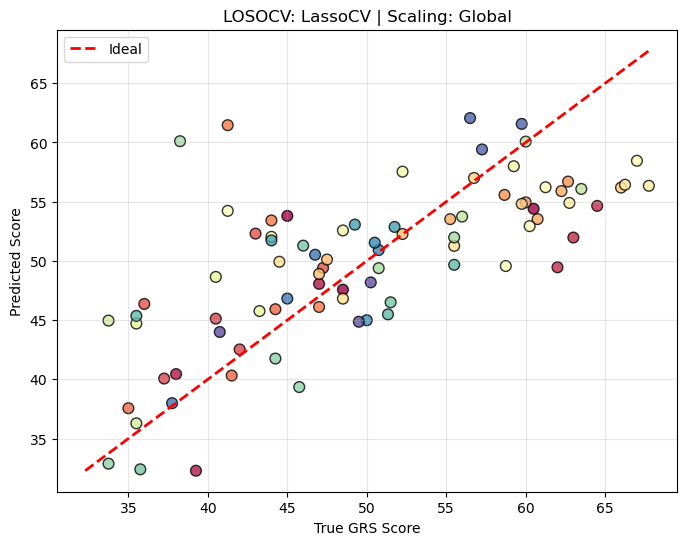

In [37]:
from sklearn.linear_model import LassoCV

_, _, _ = evaluate_loso_model(df_combined, 
                              top_features, 
                              model_class=LassoCV, 
                              model_params={'alphas': np.logspace(-1, 0.5, 30)}, 
                              extra_features=candidate_features, 
                              print_fold_metrics=False, 
                              pca_components=[0])

# Test Shuffled Residuals

In [22]:
all_shuffled_r2 = []
all_shuffled_p90_spread = []
for seed in range(300):
    df_res = leakage_free_residual_analysis(df_combined, top_features, candidate_features, base_features=['Case_1', 'Case_2', 'Case_3'], top_n=2, perform_shuffle=True, seed=seed)
    top_r2 = df_res['Shuffled_R2_mean'].values[0]
    p90_spread_r2 = df_res[df_res['Feature']=='spatial_spread_p90']['Shuffled_R2_mean'].values[0]
    all_shuffled_p90_spread.append(p90_spread_r2)
    print(f"Seed {seed}: Top R2: {top_r2}")
    all_shuffled_r2.append(top_r2)

Seed 0: Top R2: 0.06527836512996697
Seed 1: Top R2: 0.0930083419736314
Seed 2: Top R2: 0.12214750668159981
Seed 3: Top R2: 0.13688713416959652
Seed 4: Top R2: 0.16715488242447438
Seed 5: Top R2: 0.09615888817211347
Seed 6: Top R2: 0.16964554488743225
Seed 7: Top R2: 0.12570266026592944
Seed 8: Top R2: 0.09228993697388081
Seed 9: Top R2: 0.11051721608496282
Seed 10: Top R2: 0.08156711775907634
Seed 11: Top R2: 0.12468067230890424
Seed 12: Top R2: 0.13688424208257213
Seed 13: Top R2: 0.10449727331642909
Seed 14: Top R2: 0.1123594251428454
Seed 15: Top R2: 0.14736353107889158
Seed 16: Top R2: 0.04675894120553542
Seed 17: Top R2: 0.0984058624254677
Seed 18: Top R2: 0.08603712111369033
Seed 19: Top R2: 0.09346552722069949
Seed 20: Top R2: 0.06397926935654137
Seed 21: Top R2: 0.11907920277048854
Seed 22: Top R2: 0.08545109946714023
Seed 23: Top R2: 0.06848821418734181
Seed 24: Top R2: 0.18970658409316213
Seed 25: Top R2: 0.07093194139540006
Seed 26: Top R2: 0.07310287655748644
Seed 27: Top R

Empirical p-value: 0.460
Z-score vs Null: 0.04


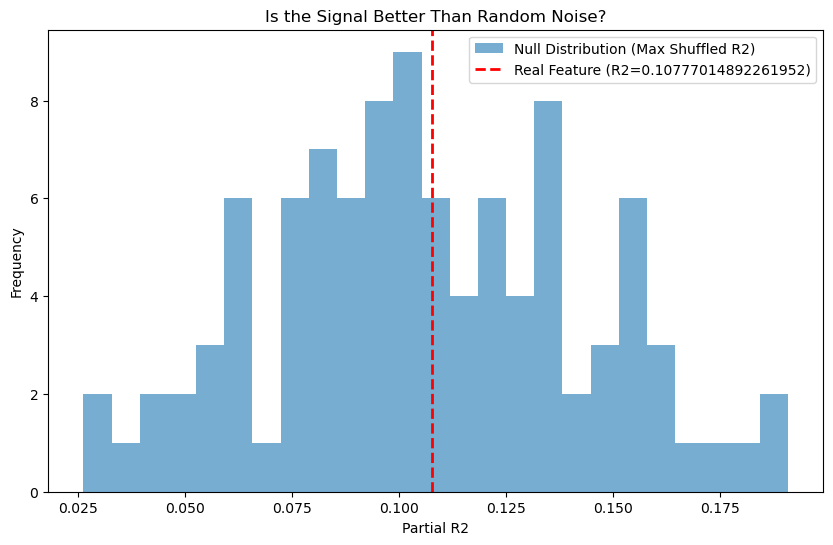

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- DATA INPUT ---
# Your top real feature R2
real_top_r2 = 0.10777014892261952

# Replace this with your actual list of 50 'Max' Shuffled R2 values 
# (The highest R2 observed in each of the 50 shuffle runs)

shuffled_max_r2s = all_shuffled_r2[::3] # your 50 max values

def evaluate_significance(real_val, null_distribution):
    null_distribution = np.array(null_distribution)
    
    # Empirical p-value: what fraction of the null is >= our real signal?
    p_value = np.mean(null_distribution >= real_val)
    
    # Z-score: how many standard deviations is the real signal from the null mean?
    z_score = (real_val - np.mean(null_distribution)) / np.std(null_distribution)
    
    return p_value, z_score

p_val, z_score = evaluate_significance(real_top_r2, shuffled_max_r2s)

print(f"Empirical p-value: {p_val:.3f}")
print(f"Z-score vs Null: {z_score:.2f}")

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.hist(shuffled_max_r2s, bins=25, alpha=0.6, label='Null Distribution (Max Shuffled R2)')
plt.axvline(real_top_r2, color='red', linestyle='--', linewidth=2, label=f'Real Feature (R2={real_top_r2})')
plt.title("Is the Signal Better Than Random Noise?")
plt.xlabel("Partial R2")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Verdict

- The Conservative Choice is to only accept spatial spread p80 as a valid additional feature (reason statistical significance)

- A valid second choice would probably be within fold direct selection of top 2 features, slighly better performance, but likely a bit over optimistic/overfitted


## **MLP Model**


In [88]:
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble

_, _, _ = evaluate_loso_mlp_ensemble(
    model_class=PyTorchMLPEnsemble,
    df=df_combined,
    primary_features=top_features,
    extra_features=['velocity_corr']+['spatial_spread_p90'],
    model_params={'hidden_dim': 12, 'n_hidden': 1, 'n_models': 5, 'dropout': 0.1, 'batch_size': 16},
    pca_components=[0],
    print_fold_metrics=True
)

LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]
KeyboardInterrupt



In [30]:
candidate_features.remove('velocity_corr')

In [44]:
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble, run_nested_loso

df_nested_results = run_nested_loso(
    df=df_combined,
    primary_features=top_features,
    candidate_features=candidate_features,
    extra_features=['Case_1', 'Case_2', 'Case_3'],
    model_type='ridge',
    model_params={'hidden_dim': 16, 'n_hidden': 1, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
    top_n=2,
    print_fold_metrics=True,
    corr_threshold=0.8,
    pr2_threshold=0.05
)

Surgeon 1 | Train MAE: 4.5711 | Test MAE: 4.1519 | Selected Features: ['spatial_spread_median', 'spatial_spread_p75'] | Selected PR2s: [np.float64(0.0868), np.float64(0.0838)]
Surgeon 2 | Train MAE: 4.5795 | Test MAE: 3.5422 | Selected Features: ['spatial_spread_median', 'spatial_spread_p75'] | Selected PR2s: [np.float64(0.1012), np.float64(0.0801)]
Surgeon 3 | Train MAE: 4.4631 | Test MAE: 10.6027 | Selected Features: ['spatial_spread_median', 'spatial_spread_p75'] | Selected PR2s: [np.float64(0.1516), np.float64(0.1059)]
Surgeon 4 | Train MAE: 4.6743 | Test MAE: 2.0970 | Selected Features: ['spatial_spread_median', 'spatial_spread_p75'] | Selected PR2s: [np.float64(0.0894), np.float64(0.0777)]
Surgeon 5 | Train MAE: 4.4793 | Test MAE: 7.5752 | Selected Features: ['spatial_spread_median', 'spatial_spread_p75'] | Selected PR2s: [np.float64(0.1272), np.float64(0.0961)]
Surgeon 6 | Train MAE: 4.7278 | Test MAE: 1.5080 | Selected Features: ['spatial_spread_median', 'spatial_spread_p75'] |

ridge with p80 no idle and vel_corr already as a feature
=== Nested LOSO Summary (ridge) ===
MAE: 4.7791 +/- 3.3512
Train MAE: 4.2873
Spearman R: 0.7996

Feature Selection Stability:
spatial_spread_p80       1.0
palm_area_cv_p20         1.0
spatial_spread_median    1.0


without vel corr as feature:
=== Nested LOSO Summary (ridge) ===
MAE: 4.7423 +/- 3.5384
Train MAE: 4.3503
Spearman R: 0.7804

Feature Selection Stability:
velocity_corr         1.0
palm_area_cv_p20      1.0
spatial_spread_p80    1.0

with MLP {'hidden_dim': 24, 'n_hidden': 2, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
=== Nested LOSO Summary (mlp) ===
MAE: 4.6731 +/- 3.5582
Train MAE: 3.4889
Spearman R: 0.7798

Feature Selection Stability:
spatial_spread_p80       1.0
palm_area_cv_p20         1.0
spatial_spread_median    1.0
Name: count, dtype: float64

=== Nested LOSO Summary (mlp) ===
MAE: 4.7600 +/- 3.4687
Train MAE: 3.8513
Spearman R: 0.7787

{'hidden_dim': 16, 'n_hidden': 1, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
Feature Selection Stability:
spatial_spread_p80       1.0
palm_area_cv_p20         1.0
spatial_spread_median    1.0
Name: count, dtype: float64

Make a plot of perfromance metrics over top_n selected features
=> this proves local signal is there but here we would need ot peek at the test data to pick the top_n parameter...

LOSOCV Folds:   0%|          | 0/28 [00:00<?, ?it/s]

/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.029e-01, tolerance: 5.093e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.463e-01, tolerance: 5.093e-01
  model = cd_fast.enet_coordinate_descent_gram(
LOSOCV Folds:  11%|█         | 3/28 [00:00<00:05,  4.82it/s]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not con


=== LOSOCV Results (Global Scaling) ===
R: 0.7473 | MAE: 4.9725 | MAE STD: 3.6580 | R2: 0.5602 | Adj R2: 0.3195

Feature Weights:
                  Feature  Average_Weight  Std_Weight
0                    bias       49.938586    0.302804
1                     PC1       -2.756005    0.131387
2           velocity_corr       -1.746163    0.214804
3    total_duration_Right        0.000000    0.000000
4               idle_prop       -0.072889    0.142618
5              zvr_median        0.000000    0.000000
6                 zvr_std        0.000000    0.000000
7                 zvr_p75        0.000000    0.000000
8                 zvr_p25        0.033437    0.160864
9          vel_p90_median        0.000000    0.000000
10            vel_p90_std        0.262446    0.326388
11            vel_p90_p75       -0.044791    0.232740
12            vel_p90_p25        0.000000    0.000000
13  spatial_spread_median       -1.670295    0.282933
14     spatial_spread_std       -0.000899    0.004672
15   

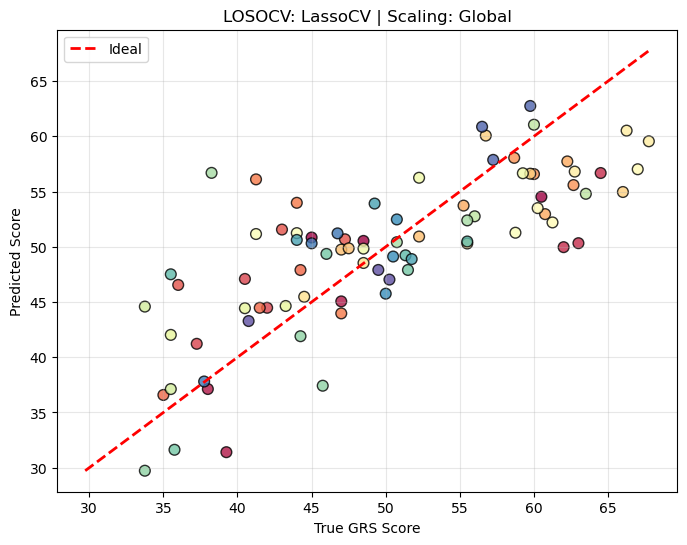

In [62]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

_, _, _ = evaluate_loso_model(df_combined, top_features_right, model_class=LassoCV, model_params={'alphas': np.logspace(-2, 2, 40)},extra_features=candidate_features, print_fold_metrics=True, pca_components=[0])